# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Rivera, Kyle Florian
- _Student No._: 2024-16197
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` (for more info, check bottomost cell under Section 3). Make sure the figure has complete elements.

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussion here. This is not related to Problem 1. Discuss your key results with ~150 words.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
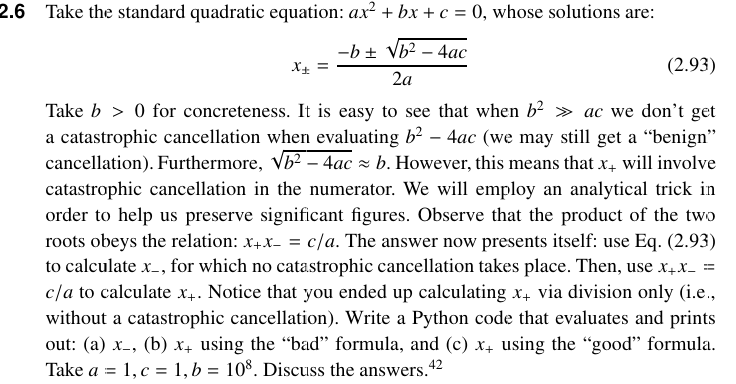

In [2]:
def calculate_disc(a, b, c): # calculate discriminant for brevity)
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return False
    return discriminant

def minus_root(a, b, c):
    disc_sqr = m.sqrt(calculate_disc(a, b, c))
    m_root = -(b + disc_sqr) / (2*a)
    return m_root

def bad_plus_root(a, b, c): 
    disc_sqr = m.sqrt(calculate_disc(a, b, c))
    bad_p_root = -(b - disc_sqr) / (2*a)
    return bad_p_root

def good_plus_root(a, b, c): # calculating positive root using product of roots formula
    good_p_root = c / (a*minus_root(a, b, c))
    return good_p_root

In [83]:
# initialize variables
a = 1
b = 1e8 # 10^8
c = 1

if calculate_disc(a, b, c) != False:
    item_1 = minus_root(a, b, c)
    item_2 = bad_plus_root(a, b, c)
    item_3 = good_plus_root(a, b, c)
    difference = abs(item_2 - item_3)
    err = abs(difference / item_3)
    print(f"minus root: {item_1}\nbad plus root: {item_2}\ngood plus root: {item_3}\n\ndifference (plusroot): {difference}\nerror (rel. to good root): {err*100}%")
else:
    print("No real solutions.")

minus root: -100000000.0
bad plus root: -7.450580596923828e-09
good plus root: -1e-08

difference (plusroot): 2.549419403076172e-09
error (rel. to good root): 25.49419403076172%


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur?
    - Catastrophic cancellation occurs when $x >> 1$.
- How can we rewrite the function to avoid catastrophic cancellation?
    - We can multiply by the conjugate in order to remove the subtraction operation:
      $$\begin{align}
      f(x) = \sqrt{x^2 + x} - x = (\sqrt{x^2 + x} - x) \left(\frac{\sqrt{x^2 + x} + x}{\sqrt{x^2 + x} + x} \right) = \frac{x}{\sqrt{x^2 + x} + x} 
      \end{align}
      $$

- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [81]:
def f(x):
    return np.sqrt(x*x + x) - x

def better_f(x):
    return x / (np.sqrt(x*x + x) + x)

x = np.logspace(0, 30, 100000)
y_1 = f(x)
y_2 = better_f(x)

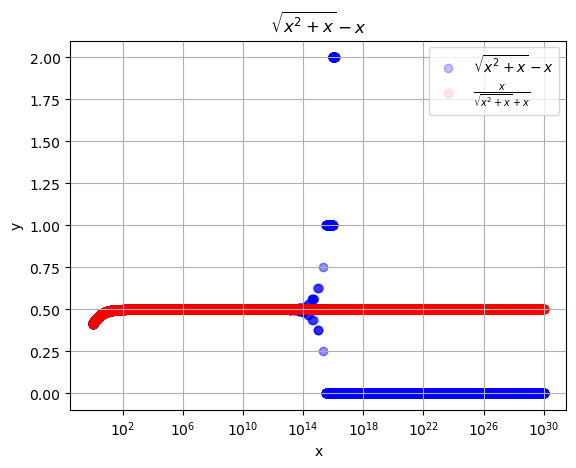

In [82]:
fig, ax = plt.subplots()

plt.title(r"$\sqrt{x^2 + x} - x$")
ax.scatter(x, y_1, color = "blue", label = r"$\sqrt{x^2 + x} - x$", alpha = 0.25)
ax.scatter(x, y_2, color = "red", label = r"$\frac{x}{\sqrt{x^2 + x} + x}$", alpha = 0.1)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.legend()
ax.grid("True")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("tight")

plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur?
    - Catastrophic cancellation occurs when $x << 1$.
- How can we resolve the catastrophic cancellation?
    - We can transform the denominator and get the following:
      $$
        g(x) = \frac{e^x - 1}{x} =  \frac{e^x - 1}{\ln(e^x)}
      $$
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [70]:
def g(x):
    return (np.exp(x) - 1) / x

def better_g(x):
    return (np.exp(x) - 1) / (np.log(np.exp(x)))

x = np.logspace(-16, -0.25, 100)
y_1 = g(x)
y_2 = better_g(x)

/tmp/ipykernel_2267266/3642793693.py:5: RuntimeWarning: invalid value encountered in divide
  return (np.exp(x) - 1) / (np.log(np.exp(x)))


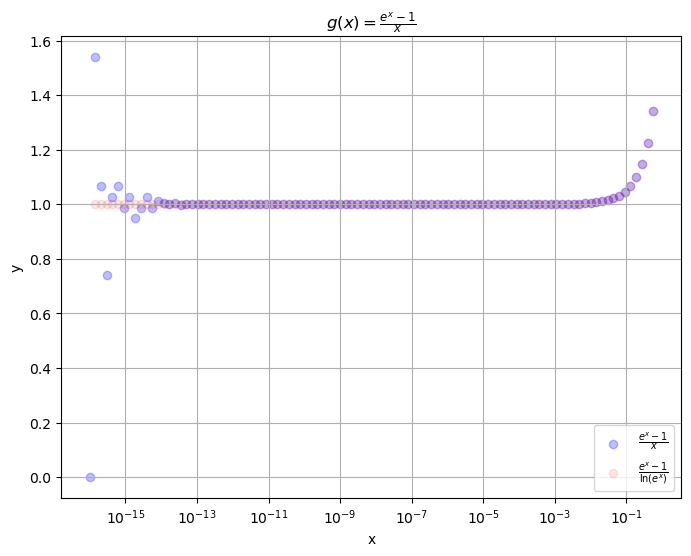

In [79]:
fig, ax = plt.subplots(figsize = (8, 6))

plt.title(r"$g(x) = \frac{e^x - 1}{x}$")
ax.scatter(x, y_1, color = "blue", label = r"$\frac{e^x - 1}{x}$", alpha = 0.25)
ax.scatter(x, y_2, color = "red", label = r"$\frac{e^x - 1}{\ln(e^x)}$", alpha = 0.1)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.legend(loc = "lower right")
ax.grid("True")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("tight")
plt.show()

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [76]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(3, 7) + Fraction(2, 7)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.7142857142857143
